In [2]:
#딥러닝을 이용한 이미지분류

import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

In [3]:
(train_images, train_labels),(test_images,test_labels)=cifar10.load_data()

In [4]:
print(train_images.shape, train_labels.shape)
print(test_images.shape, test_labels.shape)

(50000, 32, 32, 3) (50000, 1)
(10000, 32, 32, 3) (10000, 1)


In [5]:
train_images[0]

array([[[ 59,  62,  63],
        [ 43,  46,  45],
        [ 50,  48,  43],
        ...,
        [158, 132, 108],
        [152, 125, 102],
        [148, 124, 103]],

       [[ 16,  20,  20],
        [  0,   0,   0],
        [ 18,   8,   0],
        ...,
        [123,  88,  55],
        [119,  83,  50],
        [122,  87,  57]],

       [[ 25,  24,  21],
        [ 16,   7,   0],
        [ 49,  27,   8],
        ...,
        [118,  84,  50],
        [120,  84,  50],
        [109,  73,  42]],

       ...,

       [[208, 170,  96],
        [201, 153,  34],
        [198, 161,  26],
        ...,
        [160, 133,  70],
        [ 56,  31,   7],
        [ 53,  34,  20]],

       [[180, 139,  96],
        [173, 123,  42],
        [186, 144,  30],
        ...,
        [184, 148,  94],
        [ 97,  62,  34],
        [ 83,  53,  34]],

       [[177, 144, 116],
        [168, 129,  94],
        [179, 142,  87],
        ...,
        [216, 184, 140],
        [151, 118,  84],
        [123,  92,  72]]

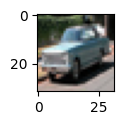

In [6]:
plt.figure(figsize=(1,1))
plt.imshow(train_images[32])

In [7]:
train_images=train_images/255.0
test_images=test_images/255.0

In [8]:
train_images[0]

array([[[0.23137255, 0.24313725, 0.24705882],
        [0.16862745, 0.18039216, 0.17647059],
        [0.19607843, 0.18823529, 0.16862745],
        ...,
        [0.61960784, 0.51764706, 0.42352941],
        [0.59607843, 0.49019608, 0.4       ],
        [0.58039216, 0.48627451, 0.40392157]],

       [[0.0627451 , 0.07843137, 0.07843137],
        [0.        , 0.        , 0.        ],
        [0.07058824, 0.03137255, 0.        ],
        ...,
        [0.48235294, 0.34509804, 0.21568627],
        [0.46666667, 0.3254902 , 0.19607843],
        [0.47843137, 0.34117647, 0.22352941]],

       [[0.09803922, 0.09411765, 0.08235294],
        [0.0627451 , 0.02745098, 0.        ],
        [0.19215686, 0.10588235, 0.03137255],
        ...,
        [0.4627451 , 0.32941176, 0.19607843],
        [0.47058824, 0.32941176, 0.19607843],
        [0.42745098, 0.28627451, 0.16470588]],

       ...,

       [[0.81568627, 0.66666667, 0.37647059],
        [0.78823529, 0.6       , 0.13333333],
        [0.77647059, 0

In [9]:
val_images=train_images[45000:]
val_labels=train_labels[45000:]

train_images=train_images[:45000]
train_labels=train_labels[:45000]

In [10]:
mlp_model = Sequential([
    Flatten(input_shape = (32, 32, 3)),
    Dense(512, activation = 'relu'),
    Dense(256, activation = 'relu'),
    Dense(128, activation = 'relu'),
    Dense(10, activation = 'softmax'),
])

In [11]:
mlp_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 3072)              0         
                                                                 
 dense (Dense)               (None, 512)               1573376   
                                                                 
 dense_1 (Dense)             (None, 256)               131328    
                                                                 
 dense_2 (Dense)             (None, 128)               32896     
                                                                 
 dense_3 (Dense)             (None, 10)                1290      
                                                                 
Total params: 1738890 (6.63 MB)
Trainable params: 1738890 (6.63 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [12]:
mlp_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [13]:
mlp_model.fit(train_images,train_labels,epochs=5,validation_data=(val_images,val_labels))

Epoch 1/5


1407/1407 [==============================] - 5s 4ms/step - loss: 1.8750 - accuracy: 0.3169 - val_loss: 1.7759 - val_accuracy: 0.3686
Epoch 2/5
1407/1407 [==============================] - 5s 4ms/step - loss: 1.6868 - accuracy: 0.3936 - val_loss: 1.6928 - val_accuracy: 0.3962
Epoch 3/5
1407/1407 [==============================] - 5s 4ms/step - loss: 1.6070 - accuracy: 0.4233 - val_loss: 1.6327 - val_accuracy: 0.4200
Epoch 4/5
1407/1407 [==============================] - 5s 4ms/step - loss: 1.5510 - accuracy: 0.4438 - val_loss: 1.5563 - val_accuracy: 0.4492
Epoch 5/5
1407/1407 [==============================] - 5s 4ms/step - loss: 1.5141 - accuracy: 0.4572 - val_loss: 1.5060 - val_accuracy: 0.4590


In [14]:
mlp_model.evaluate(test_images,test_labels)

313/313 [==============================] - 0s 1ms/step - loss: 1.4989 - accuracy: 0.4669


[1.4988600015640259, 0.4668999910354614]

In [15]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout

In [16]:
cnn_model=Sequential([
    Conv2D(32,(3,3),padding='same',activation='relu',input_shape=(32,32,3)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3),padding='same', activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(64,(3,3),padding='same',activation='relu'),
    Flatten(),
    Dropout(0.3),
    Dense(64,activation='relu'),
    Dropout(0.5),
    Dense(10,activation='softmax')
])

In [17]:
cnn_model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 32, 32, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 16, 16, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 16, 16, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 8, 8, 64)          0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 8, 8, 64)          36928     
                                                                 
 flatten_1 (Flatten)         (None, 4096)             

In [18]:
cnn_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

In [19]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stopping=EarlyStopping(monitor='val_loss',patience=5)
save_best_only=ModelCheckpoint('best_cifar10_cnn_model.h5',save_best_only=True)

In [20]:
history=cnn_model.fit(train_images, train_labels, batch_size=512, epochs=100, validation_data=(val_images,val_labels),
                      callbacks=[early_stopping, save_best_only])

Epoch 1/100
88/88 [==============================] - 5s 52ms/step - loss: 1.9681 - accuracy: 0.2768 - val_loss: 1.6066 - val_accuracy: 0.4270
Epoch 2/100
 3/88 [>.............................] - ETA: 4s - loss: 1.7336 - accuracy: 0.3789

c:\Users\wm032\Documents\이미지처리바이블\.venv\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


88/88 [==============================] - 5s 54ms/step - loss: 1.6243 - accuracy: 0.4094 - val_loss: 1.4064 - val_accuracy: 0.5000
Epoch 3/100
88/88 [==============================] - 5s 51ms/step - loss: 1.4844 - accuracy: 0.4643 - val_loss: 1.2960 - val_accuracy: 0.5492
Epoch 4/100
88/88 [==============================] - 4s 51ms/step - loss: 1.3959 - accuracy: 0.4984 - val_loss: 1.2268 - val_accuracy: 0.5696
Epoch 5/100
88/88 [==============================] - 4s 51ms/step - loss: 1.3191 - accuracy: 0.5285 - val_loss: 1.1301 - val_accuracy: 0.6056
Epoch 6/100
88/88 [==============================] - 5s 53ms/step - loss: 1.2621 - accuracy: 0.5506 - val_loss: 1.0731 - val_accuracy: 0.6300
Epoch 7/100
88/88 [==============================] - 5s 56ms/step - loss: 1.2002 - accuracy: 0.5732 - val_loss: 1.0086 - val_accuracy: 0.6474
Epoch 8/100
88/88 [==============================] - 5s 56ms/step - loss: 1.1543 - accuracy: 0.5897 - val_loss: 1.0265 - val_accuracy: 0.6388
Epoch 9/100
88/88 

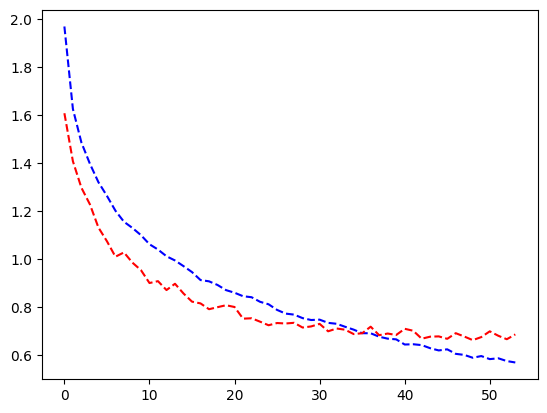

In [21]:
plt.plot(history.history['loss'],'b--')
plt.plot(history.history['val_loss'],'r--')
plt.show()

In [22]:
cnn_model.evaluate(test_images,test_labels)

313/313 [==============================] - 1s 2ms/step - loss: 0.7280 - accuracy: 0.7621


[0.7280157804489136, 0.7620999813079834]

In [23]:
predicted_labels=cnn_model.predict(test_images)
predicted_labels.shape

313/313 [==============================] - 1s 2ms/step


(10000, 10)

In [24]:
import tensorflow as tf

predicted_labels=tf.argmax(predicted_labels,axis=1)
predicted_labels

<tf.Tensor: shape=(10000,), dtype=int64, numpy=array([3, 8, 0, ..., 5, 4, 7], dtype=int64)>

In [25]:
label_to_name={
    0:'arrplane', 1:'automobile', 2:'bird', 3:'cat', 4:'deer', 5:'dog', 6:'frog', 7:'horse', 8:'ship', 9:'truck'
}

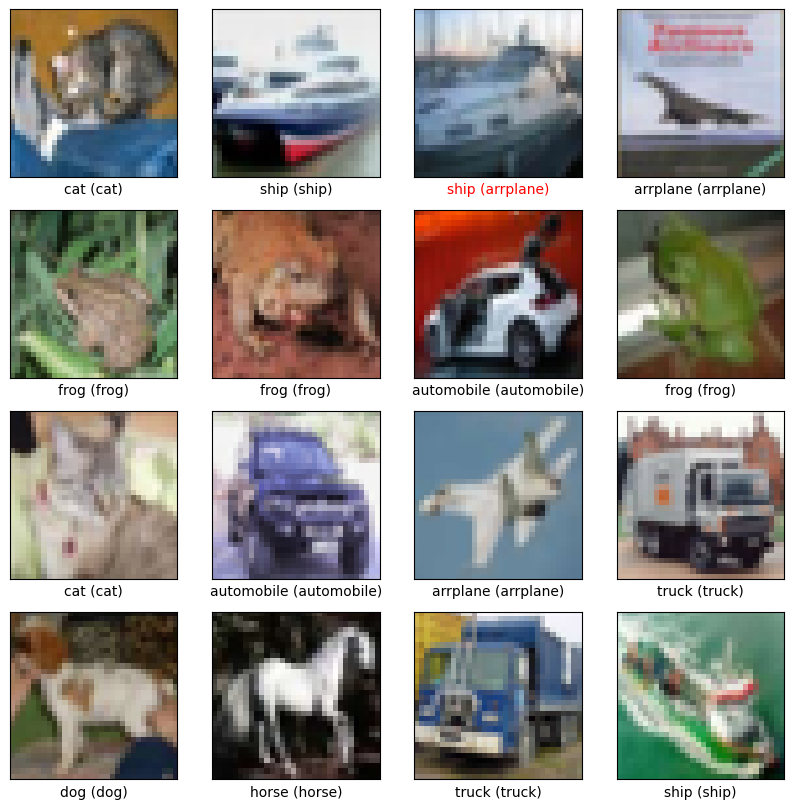

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(test_images[i],cmap=plt.cm.binary)
    xlabel=f"{label_to_name[int(test_labels[i][0])]} ({label_to_name[int(predicted_labels[i])]})"
    plt.xlabel(xlabel,color='red' if test_labels[i][0] !=predicted_labels[i] else 'black')